In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# function to turn a chemical formula into Hill notation
def hill_notation(formula):
    from collections import defaultdict
    import re

    # Regular expression to match elements and their counts
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, formula)
    if not matches:
        return formula

    element_counts = defaultdict(int)
    for element, count in matches:
        element_counts[element] += int(count) if count else 1

    # If the formula contains only a single element, return it unchanged
    # (show count only if >1; e.g. 'Zn' -> 'Zn', 'O2' -> 'O2')
    if len(element_counts) == 1:
        el, cnt = next(iter(element_counts.items()))
        return el if cnt == 1 else f"{el}{cnt}"

    # Build Hill-style string (C/H ordering commented out; keep numeric '1' for multi-element parts)
    hill_list = []
    for element in sorted(element_counts.keys()):
        count = element_counts[element]
        hill_list.append(f'{element}{count}')

    return ''.join(hill_list)


In [3]:
hill_notation('H2O')  # Example usage

'H2O1'

In [15]:
comp = "EH3"

In [17]:
mon = pd.read_csv(f'input/chemistry/{comp}/monitor_daniel.dat', sep='\\s+')

In [18]:
df = pd.read_csv(f'input/chemistry/{comp}/chem_daniel.dat', sep='\\s+')

In [6]:
mon

,#grid_point,iterations,chem_iter,cond_iter,converged,elem_conserved,p(bar),T(K),n_<tot>(cm-3),n_g(cm-3),...,Mn,N,Na,Ni,O,P,S,Si,Ti,Zn
0,0,1649,11764,4456,ok,ok,0.000001,100.0,1.526017e+16,7.242971e+13,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
1,1,1657,11774,4490,ok,ok,0.000002,100.0,3.288547e+16,1.560451e+14,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
2,2,1661,11777,4486,ok,ok,0.000005,100.0,7.085801e+16,3.361889e+14,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
3,3,1662,11784,4455,ok,ok,0.000010,100.0,1.526674e+17,7.242971e+14,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
4,4,1662,11797,4468,ok,ok,0.000022,100.0,3.289204e+17,1.560451e+15,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,3327,0,15,0,ok,ok,46.415890,6000.0,6.825875e+19,5.603149e+19,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
3328,3328,0,14,0,ok,ok,100.000000,6000.0,1.533881e+20,1.207162e+20,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
3329,3329,0,16,0,ok,ok,215.443500,6000.0,3.488319e+20,2.600752e+20,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
3330,3330,0,16,0,ok,ok,464.158900,6000.0,8.009363e+20,5.603149e+20,...,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok


(100.0, 1500.0)

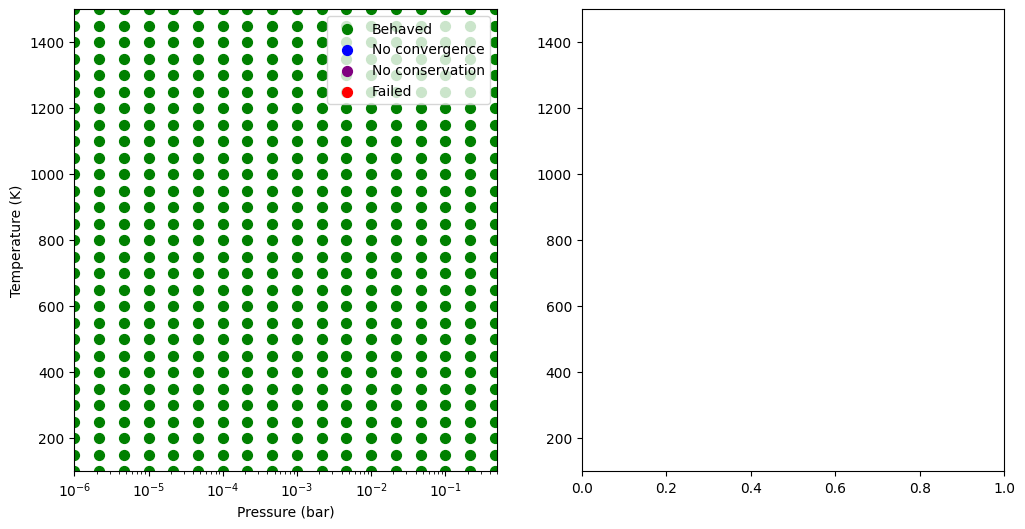

In [19]:
fig,[ax1,ax2] = plt.subplots(figsize=(12, 6), ncols=2)
behaved = (mon['converged'] == 'ok') & (mon['elem_conserved'] == 'ok')
ax1.scatter(mon[behaved]['p(bar)'], mon[behaved]['T(K)'], s=50, color='green', label = 'Behaved')

no_conv = (mon['converged'] != 'ok') & (mon['elem_conserved'] == 'ok')
ax1.scatter(mon[no_conv]['p(bar)'], mon[no_conv]['T(K)'], s=50, color='blue', label = 'No convergence')

no_cons = (mon['converged'] == 'ok') & (mon['elem_conserved'] != 'ok')
ax1.scatter(mon[no_cons]['p(bar)'], mon[no_cons]['T(K)'], s=50, color='purple', label = 'No conservation')

failed = (mon['converged'] != 'ok') & (mon['elem_conserved'] != 'ok')
ax1.scatter(mon[failed]['p(bar)'], mon[failed]['T(K)'], s=50, color='red', label = 'Failed')
ax1.set_xscale('log')
ax1.set_xlabel('Pressure (bar)')
ax1.set_ylabel('Temperature (K)')
ax1.legend()
ax1.set_xlim(1e-6, 5e-1)
ax1.set_ylim(100, 1500)

# behaved = (mon_daniel['converged'] == 'ok') & (mon_daniel['elem_conserved'] == 'ok')
# ax2.scatter(mon_daniel[behaved]['p(bar)'], mon_daniel[behaved]['T(K)'], s=50, color='green', label = 'Behaved')

# no_conv = (mon_daniel['converged'] != 'ok') & (mon_daniel['elem_conserved'] == 'ok')
# ax2.scatter(mon_daniel[no_conv]['p(bar)'], mon_daniel[no_conv]['T(K)'], s=50, color='blue', label = 'No convergence')

# no_cons = (mon_daniel['converged'] == 'ok') & (mon_daniel['elem_conserved'] != 'ok')
# ax2.scatter(mon_daniel[no_cons]['p(bar)'], mon_daniel[no_cons]['T(K)'], s=50, color='purple', label = 'No conservation')

# failed = (mon_daniel['converged'] != 'ok') & (mon_daniel['elem_conserved'] != 'ok')
# ax2.scatter(mon_daniel[failed]['p(bar)'], mon_daniel[failed]['T(K)'], s=50, color='red', label = 'Failed')
# ax2.set_xscale('log')
# ax2.set_xlabel('Pressure (bar)')
# ax2.set_ylabel('Temperature (K)')
# ax2.legend()
# ax2.set_xlim(1e-6, 5e-1)
ax2.set_ylim(100, 1500)

KeyError: 'vmr_sum'

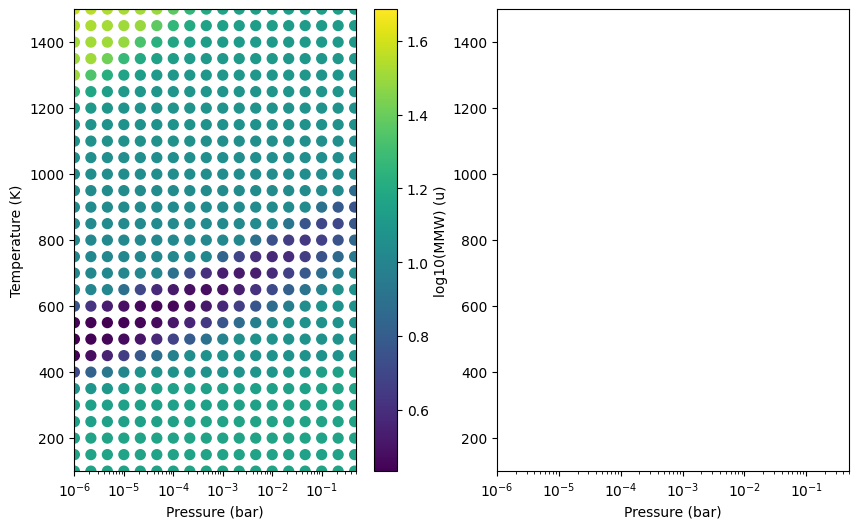

In [20]:
fig, axes = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
for ax in axes:
    ax.set_xscale('log')
    if ax == axes[0]:
        ax.set_ylabel('Temperature (K)')
    ax.set_xlabel('Pressure (bar)')
    ax.set_xlim(1e-6, 5e-1)
    ax.set_ylim(100, 1500)
sc0 = axes[0].scatter(df['#p(bar)'], df['T(K)'], s=50, c=np.log10(df['m(u)']), cmap='viridis')
fig.colorbar(sc0, ax=axes[0], label='log10(MMW) (u)')

sc1 = axes[1].scatter(df['#p(bar)'], df['T(K)'], s=50, c=df['vmr_sum'], cmap='viridis')
fig.colorbar(sc1, ax=axes[1], label='VMR Sum')

In [9]:
df

,#p(bar),T(K),n_<tot>(cm-3),n_g(cm-3),m(u),e-,Al,C,Ca,Cl,...,P1+,P1-,S1+,S1-,Si1+,Si1-,Ti1+,Ti1-,Zn1+,Zn1-
0,0.000001,100.0,6.525253e+15,7.242971e+13,14.334749,1.892100e-193,0.000000,0.000000e+00,0.000000,7.547911e-170,...,0.000000e+00,0.000000e+00,0.000000e+00,2.594262e-278,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.516840e-301
1,0.000002,100.0,1.406183e+16,1.560451e+14,14.334059,8.782351e-194,0.000000,0.000000e+00,0.000000,3.503430e-170,...,0.000000e+00,0.000000e+00,0.000000e+00,1.204150e-278,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.040549e-302
2,0.000005,100.0,3.029890e+16,3.361889e+14,14.333739,4.076406e-194,0.000000,0.000000e+00,0.000000,1.626148e-170,...,0.000000e+00,0.000000e+00,0.000000e+00,5.589168e-279,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.267934e-302
3,0.000010,100.0,6.528060e+16,7.242971e+14,14.333591,1.892100e-194,0.000000,0.000000e+00,0.000000,7.547911e-171,...,0.000000e+00,0.000000e+00,0.000000e+00,2.594262e-279,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.516840e-302
4,0.000022,100.0,1.406464e+17,1.560451e+15,14.333522,8.782351e-195,0.000000,0.000000e+00,0.000000,3.503430e-171,...,0.000000e+00,0.000000e+00,0.000000e+00,1.204150e-279,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.040549e-303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,46.415890,6000.0,7.105626e+19,5.603149e+19,31.150075,4.723428e-03,0.006944,5.969915e-06,0.004891,9.389114e-05,...,7.753688e-09,3.217305e-07,2.673239e-07,1.401431e-04,9.460361e-06,0.000015,2.224188e-06,8.041224e-09,2.736075e-08,1.760569e-08
3328,100.000000,6000.0,1.611917e+20,1.207162e+20,32.799404,3.077954e-03,0.005635,3.274979e-06,0.004500,9.006636e-05,...,3.534903e-09,2.890931e-07,1.651537e-07,1.706469e-04,3.835052e-06,0.000012,9.184572e-07,6.544642e-09,2.052106e-08,2.602562e-08
3329,215.443500,6000.0,3.692938e+20,2.600752e+20,34.878834,1.888982e-03,0.004261,1.909669e-06,0.003849,8.272347e-05,...,1.650431e-09,2.359692e-07,1.012337e-07,1.828661e-04,1.735146e-06,0.000009,3.907122e-07,4.867229e-09,1.650382e-08,3.659178e-08
3330,464.158900,6000.0,8.501733e+20,5.603149e+20,37.270409,1.082484e-03,0.003076,1.182987e-06,0.003083,7.157899e-05,...,8.207447e-10,1.788630e-07,6.253078e-08,1.721695e-04,8.910697e-07,0.000007,1.775931e-07,3.372137e-09,1.428370e-08,4.827188e-08


In [8]:
df['vmr_sum'] = 0
for col in df.columns:
    if "(" in col:
        continue
    if col == 'vmr_sum':
        continue
    df['vmr_sum'] += df[col]

In [12]:
for col in df.columns:
    if "(" in col:
        continue
    if col == 'vmr_sum':
        continue
    df[col] = df[col] / df['vmr_sum']
df["m(u)"] = df["m(u)"] / df['vmr_sum']

In [13]:
df['vmr_sum']

0       0.996622
1       0.996644
2       0.996655
3       0.996535
4       0.996537
          ...   
3327    1.000000
3328    0.999999
3329    0.999999
3330    1.000000
3331    1.000000
Name: vmr_sum, Length: 3332, dtype: float64

/home/cwirth/ipykernel_1334044/2814441848.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


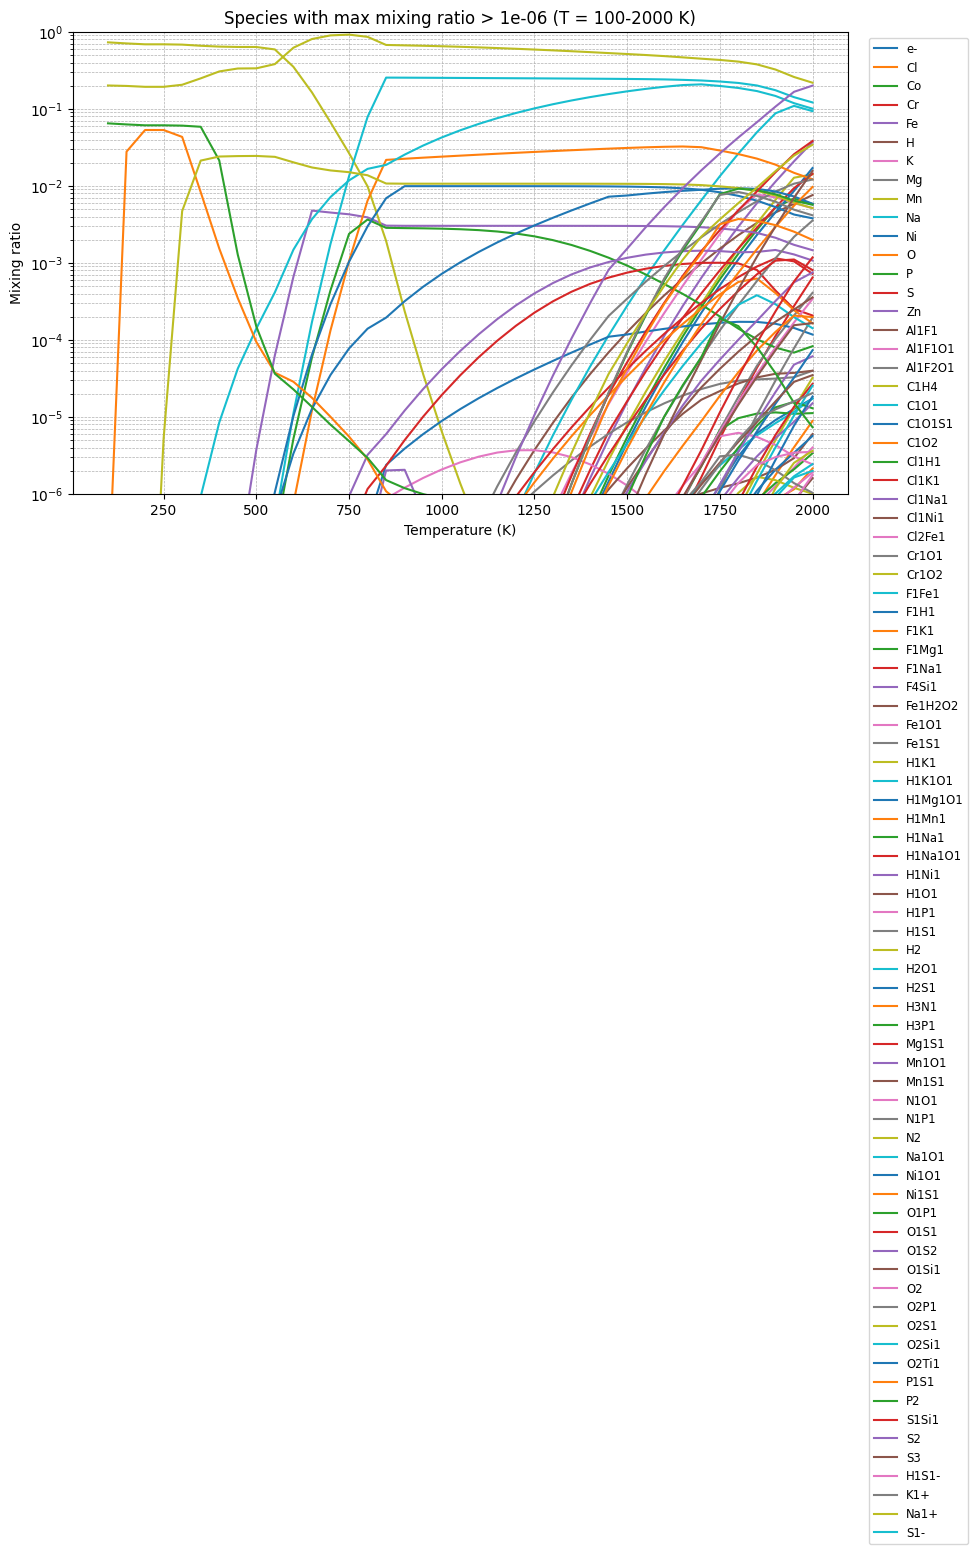

In [22]:
# select temperature column and sort rows by temperature
temp_col = 'T(K)'
df_sorted = df.sort_values(temp_col)
pressure_selected = 1e-2  # bar
df_sorted = df_sorted[df_sorted['#p(bar)'] == pressure_selected]

# restrict to temperature range 100-1500 K
temp_min, temp_max = 100, 2000
df_range = df_sorted[df_sorted[temp_col].between(temp_min, temp_max)]

# choose species whose maximum mixing ratio exceeds threshold (exclude columns with '(' like T(k))
threshold = 1e-6
species = [c for c in df.columns if '(' not in c and df_range[c].max() > threshold]

if df_range.empty:
    print(f"No rows found in temperature range {temp_min}-{temp_max} K.")
elif not species:
    print("No species found with max mixing ratio > 1e-6.")
else:
    x = df_range[temp_col]
    plt.figure(figsize=(10, 6))
    for col in species:
        plt.plot(x, df_range[col], label=col)
    plt.yscale('log')
    plt.xlabel('Temperature (K)')
    plt.ylabel('Mixing ratio')
    plt.title(f"Species with max mixing ratio > {threshold:.0e} (T = {temp_min}-{temp_max} K)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(fontsize='small', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.ylim(1e-6,1)
    plt.tight_layout()
    plt.show()
   

In [23]:
ktable_path = "ktable/input/EH3_species_table.dat"
scattering_species = ["H2", "He", "H", "H2O", "CO", "CO2", "O2", "N2", "e-"]

# compute range slice (uses existing df_sorted, temp_col, temp_min, temp_max)
df_range = df_sorted[df_sorted[temp_col].between(temp_min, temp_max)]

if df_range.empty:
    print(f"No rows in temperature range {temp_min}-{temp_max} K.")
else:
    # ensure we only consider species whose max in the range exceeds the threshold
    cols = [c for c in species if df_range[c].max() > threshold]
    if not cols:
        print(f"No species with max mixing ratio > {threshold} in {temp_min}-{temp_max} K.")
    else:
        #open file
        with open(ktable_path, 'w') as f:
            f.write("species     absorbing  scattering  mixing_ratio\n")
            means = df_range[cols].mean()
            sorted_means = means.sort_values(ascending=False)
            # print ranked list with mean and max for context
            for i, col in enumerate(sorted_means.index, 1):
                mean_val = sorted_means.loc[col]
                max_val = df_range[col].max()

                # highlight species without a corresponding folder in opacity/
                opac_dir = './opacity/'
                # compare each folder name in opacity/ to the species name
                for folder in os.listdir(opac_dir):
                    #change folder to the right format (alphabetical elements and number of atoms)
                    hill = hill_notation(folder)
                    if hill == col:
                        col_display = col
                        #print to the file
                        if folder in scattering_species:
                            f.write(f"{folder:12s} yes        yes        FastChem\n")
                        else:
                            f.write(f"{folder:12s} yes        no         FastChem\n")   
                        break
                else:
                    col_display = f"*{col}*"
                print(f"{i:2d}. {col_display:20s} mean={mean_val:.3e}    max={max_val:.3e}")
            f.write(f"e-           no         yes        FastChem\n")

 1. H2                   mean=4.910e-01    max=9.242e-01
 2. C1H4                 mean=1.875e-01    max=7.331e-01
 3. C1O1                 mean=1.449e-01    max=2.554e-01
 4. H2O1                 mean=7.619e-02    max=2.087e-01
 5. *S2*                 mean=1.662e-02    max=2.010e-01
 6. C1O2                 mean=1.619e-02    max=3.256e-02
 7. N2                   mean=1.138e-02    max=2.454e-02
 8. H3P1                 mean=1.008e-02    max=6.504e-02
 9. Na                   mean=1.008e-02    max=1.097e-01
10. F1H1                 mean=5.471e-03    max=9.941e-03
11. H3N1                 mean=4.828e-03    max=5.330e-02
12. H2S1                 mean=3.188e-03    max=9.349e-03
13. O2S1                 mean=2.514e-03    max=3.431e-02
14. O1S1                 mean=2.510e-03    max=3.836e-02
15. Zn                   mean=2.202e-03    max=4.788e-03
16. Fe                   mean=2.075e-03    max=3.721e-02
17. O1P1                 mean=1.318e-03    max=9.230e-03
18. H1S1                 mean=1

In [11]:
from dace_query.opacity import Atom, Molecule

2026-02-04 12:50:47,156 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [13]:
Atom.download('Zn', charge=0, line_list='NIST', version=1.0, temperature_boundaries=(0, 6000), pressure_boundaries=(-8, 3), output_directory='./opacity')

2026-02-04 12:51:29,266 - INFO - Downloading file on location : opacity/Zn_0_NIST.tar.gz


 Download : 382 MB

2026-02-04 12:53:11,733 - INFO - File downloaded on location : opacity/Zn_0_NIST.tar.gz


 Download : 383 MB
Download done


In [59]:
Molecule.download('24Mg-19F', line_list='MoLLIST', version=1.0, temperature_boundaries=(0, 6000), pressure_boundaries=(-8, 3), output_directory='./opacity')

2026-02-04 15:05:46,653 - INFO - Downloading file on location : opacity/24Mg-19F_MoLLIST.tar.gz


 Download : 2135 MB

2026-02-04 15:09:53,531 - INFO - File downloaded on location : opacity/24Mg-19F_MoLLIST.tar.gz


 Download : 2137 MB
Download done


In [6]:
opac = pd.read_csv('output/TRAPPIST-1b_EH3/TRAPPIST-1b_EH3_opacities.dat', sep='\\s+', skiprows=2)

In [7]:
planck = pd.read_csv('output/TRAPPIST-1b_EH3/TRAPPIST-1b_EH3_planck_cent.dat', sep='\\s+', skiprows=2)

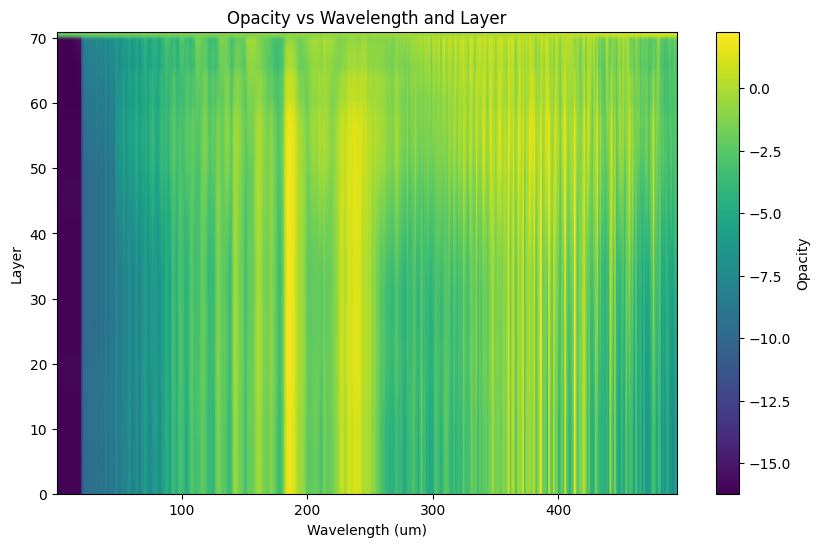

In [8]:
#make a 2D plot of opacity vs wavelength and layer
plt.figure(figsize=(10, 6))
plt.imshow(np.log10(opac.iloc[:, 3:].T), aspect='auto', extent=[opac['cent_lambda[um]'].min(), opac['cent_lambda[um]'].max(), 0, 71])
plt.colorbar(label='Opacity')
plt.xlabel('Wavelength (um)')
plt.ylabel('Layer')
plt.title('Opacity vs Wavelength and Layer')
plt.show()


Text(0.5, 1.0, 'Opacity vs Wavelength for Layer 30')

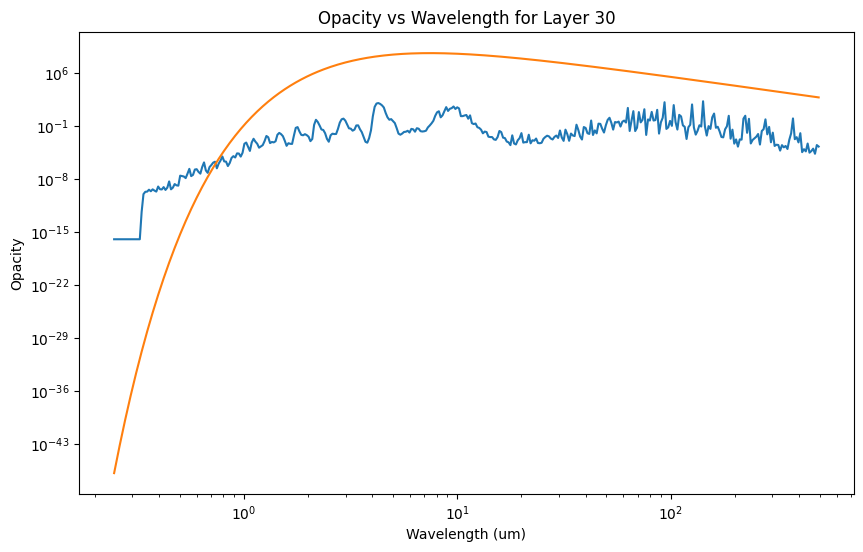

In [9]:
#plot opacity vs wavelength for a single layer
layer = 30
plt.figure(figsize=(10, 6))
plt.plot(opac['cent_lambda[um]'], opac[f'opac_lay[{layer}]'], label=f'Layer {layer}')
plt.plot(planck['cent_lambda[um]'], planck[f'B_lay[{layer}]'], label=f'Planck Layer {layer}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('Opacity')
plt.title(f'Opacity vs Wavelength for Layer {layer}')

In [10]:
planck_mean = (planck[f'B_lay[{layer}]']*opac[f'opac_lay[{layer}]']).sum() / planck[f'B_lay[{layer}]'].sum()
planck_mean

np.float64(5.45146812644806)

(1e-05, 100.0)

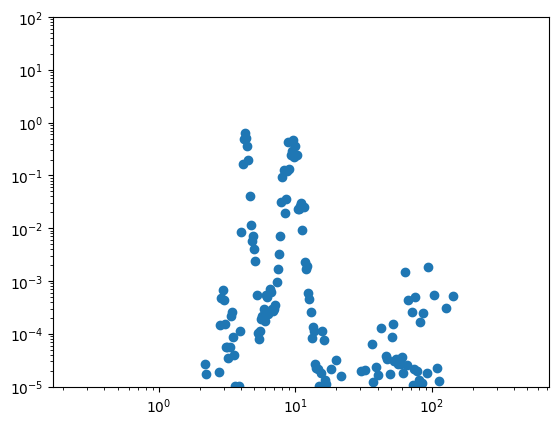

In [11]:
plt.scatter(planck['cent_lambda[um]'], (planck[f'B_lay[{layer}]']*opac[f'opac_lay[{layer}]']) / planck[f'B_lay[{layer}]'].sum())
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 1e2)

In [12]:
taus = pd.read_csv('output/TRAPPIST-1b_EH3/TRAPPIST-1b_EH3_optdepth.dat', sep='\\s+', skiprows=1)

In [13]:
taus

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],delta_tau_lay[0],delta_tau_lay[1],delta_tau_lay[2],delta_tau_lay[3],delta_tau_lay[4],delta_tau_lay[5],...,delta_tau_lay[61],delta_tau_lay[62],delta_tau_lay[63],delta_tau_lay[64],delta_tau_lay[65],delta_tau_lay[66],delta_tau_lay[67],delta_tau_lay[68],delta_tau_lay[69],delta_tau_lay[70]
0,0,0.246440,0.244000,0.004880,0.063012,0.050582,0.040615,0.032625,0.026166,0.020853,...,1.573450e-07,1.205500e-07,9.307000e-08,7.275960e-08,5.773860e-08,4.651010e-08,3.791250e-08,3.112880e-08,2.564190e-08,2.112440e-08
1,1,0.251369,0.248880,0.004978,0.057722,0.046336,0.037206,0.029886,0.023970,0.019103,...,1.441320e-07,1.104260e-07,8.525460e-08,6.664990e-08,5.289020e-08,4.260460e-08,3.472900e-08,2.851480e-08,2.348870e-08,1.935040e-08
2,2,0.256396,0.253858,0.005077,0.052892,0.042459,0.034093,0.027386,0.021964,0.017504,...,1.320690e-07,1.011850e-07,7.812010e-08,6.107240e-08,4.846420e-08,3.903930e-08,3.182270e-08,2.612850e-08,2.152300e-08,1.773100e-08
3,3,0.261524,0.258935,0.005179,0.048482,0.038919,0.031250,0.025102,0.020133,0.016045,...,1.210520e-07,9.274480e-08,7.160400e-08,5.597840e-08,4.442190e-08,3.578310e-08,2.916840e-08,2.394910e-08,1.972770e-08,1.625200e-08
4,4,0.266755,0.264113,0.005282,0.044452,0.035684,0.028653,0.023016,0.018460,0.014711,...,1.109860e-07,8.503310e-08,6.565030e-08,5.132410e-08,4.072850e-08,3.280790e-08,2.674320e-08,2.195780e-08,1.808730e-08,1.490060e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,456.852988,452.329691,9.046594,1.244090,0.680095,0.408436,0.242849,0.153938,0.119601,...,4.925970e-11,3.957860e-11,3.180030e-11,2.555080e-11,2.052970e-11,1.649530e-11,1.325390e-11,1.064940e-11,8.556800e-12,6.875370e-12
381,381,465.990048,461.376285,9.227526,0.175716,0.099718,0.061553,0.036385,0.024368,0.026691,...,1.961000e-11,1.567150e-11,1.253680e-11,1.004370e-11,8.059410e-12,6.477360e-12,5.212400e-12,4.197820e-12,3.382070e-12,2.725010e-12
382,382,475.309849,470.603811,9.412076,0.267837,0.126192,0.074588,0.041938,0.026093,0.026320,...,4.774870e-12,3.838840e-12,3.085940e-12,2.480310e-12,1.993180e-12,1.601450e-12,1.286530e-12,1.033450e-12,8.301180e-13,6.667860e-13
383,383,484.816046,480.015887,9.600318,1.715950,1.018920,0.640119,0.407267,0.274095,0.197028,...,8.299720e-11,6.137520e-11,4.586840e-11,3.500980e-11,2.746840e-11,2.217850e-11,1.831610e-11,1.532520e-11,1.288730e-11,1.082790e-11


In [14]:
taus['tau_sum'] = 0
for col in taus.columns:
    if 'tau_lay' in col:
        taus['tau_sum'] += taus[col]

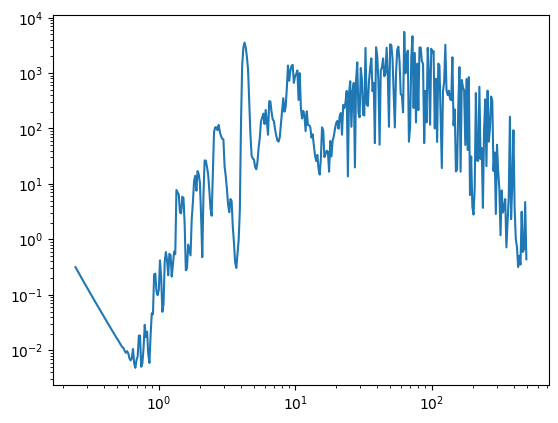

In [15]:
plt.plot(taus['cent_lambda[um]'], taus['tau_sum'])
plt.xscale('log')
plt.yscale('log')

In [16]:
layer = 0
koll_mean = -np.log(np.sum(planck[f'B_lay[{layer}]']*np.exp(-taus['tau_sum']))/ planck[f'B_lay[{layer}]'].sum())
koll_mean

np.float64(3.242387592706243)

In [20]:
koll_mean_2 = -np.log((planck[f'B_lay[{layer}]']*np.exp(-2040*opac[f'opac_lay[{layer}]'])).sum() / planck[f'B_lay[{layer}]'].sum())
koll_mean_2

np.float64(3.8726581104904705)